Import Libraries

In [1]:
import numpy as np
import phik as pk
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Import Dataset & Extract Features/Target

In [2]:
real_data = pd.read_csv('../data/scamaap dataset.csv').drop(columns=['NtsbNo','Event.Date'])
target_names = ['Supervisory Conditions','Operator Conditions','Unsafe Conditions']
y_data = real_data[target_names]
X_data = real_data.drop(columns=target_names)
feature_names = X_data.columns

## Separate Numerical & Categorical Data

In [4]:
num_data = real_data.select_dtypes(include=['float64'])
num_features = num_data.columns
num_data = pd.concat((num_data,y_data),axis=1)
cat_data = real_data.select_dtypes(exclude=['float'])
cat_features = cat_data.columns.drop(target_names)
#num_data

# Plot Feature Distribution Graphs

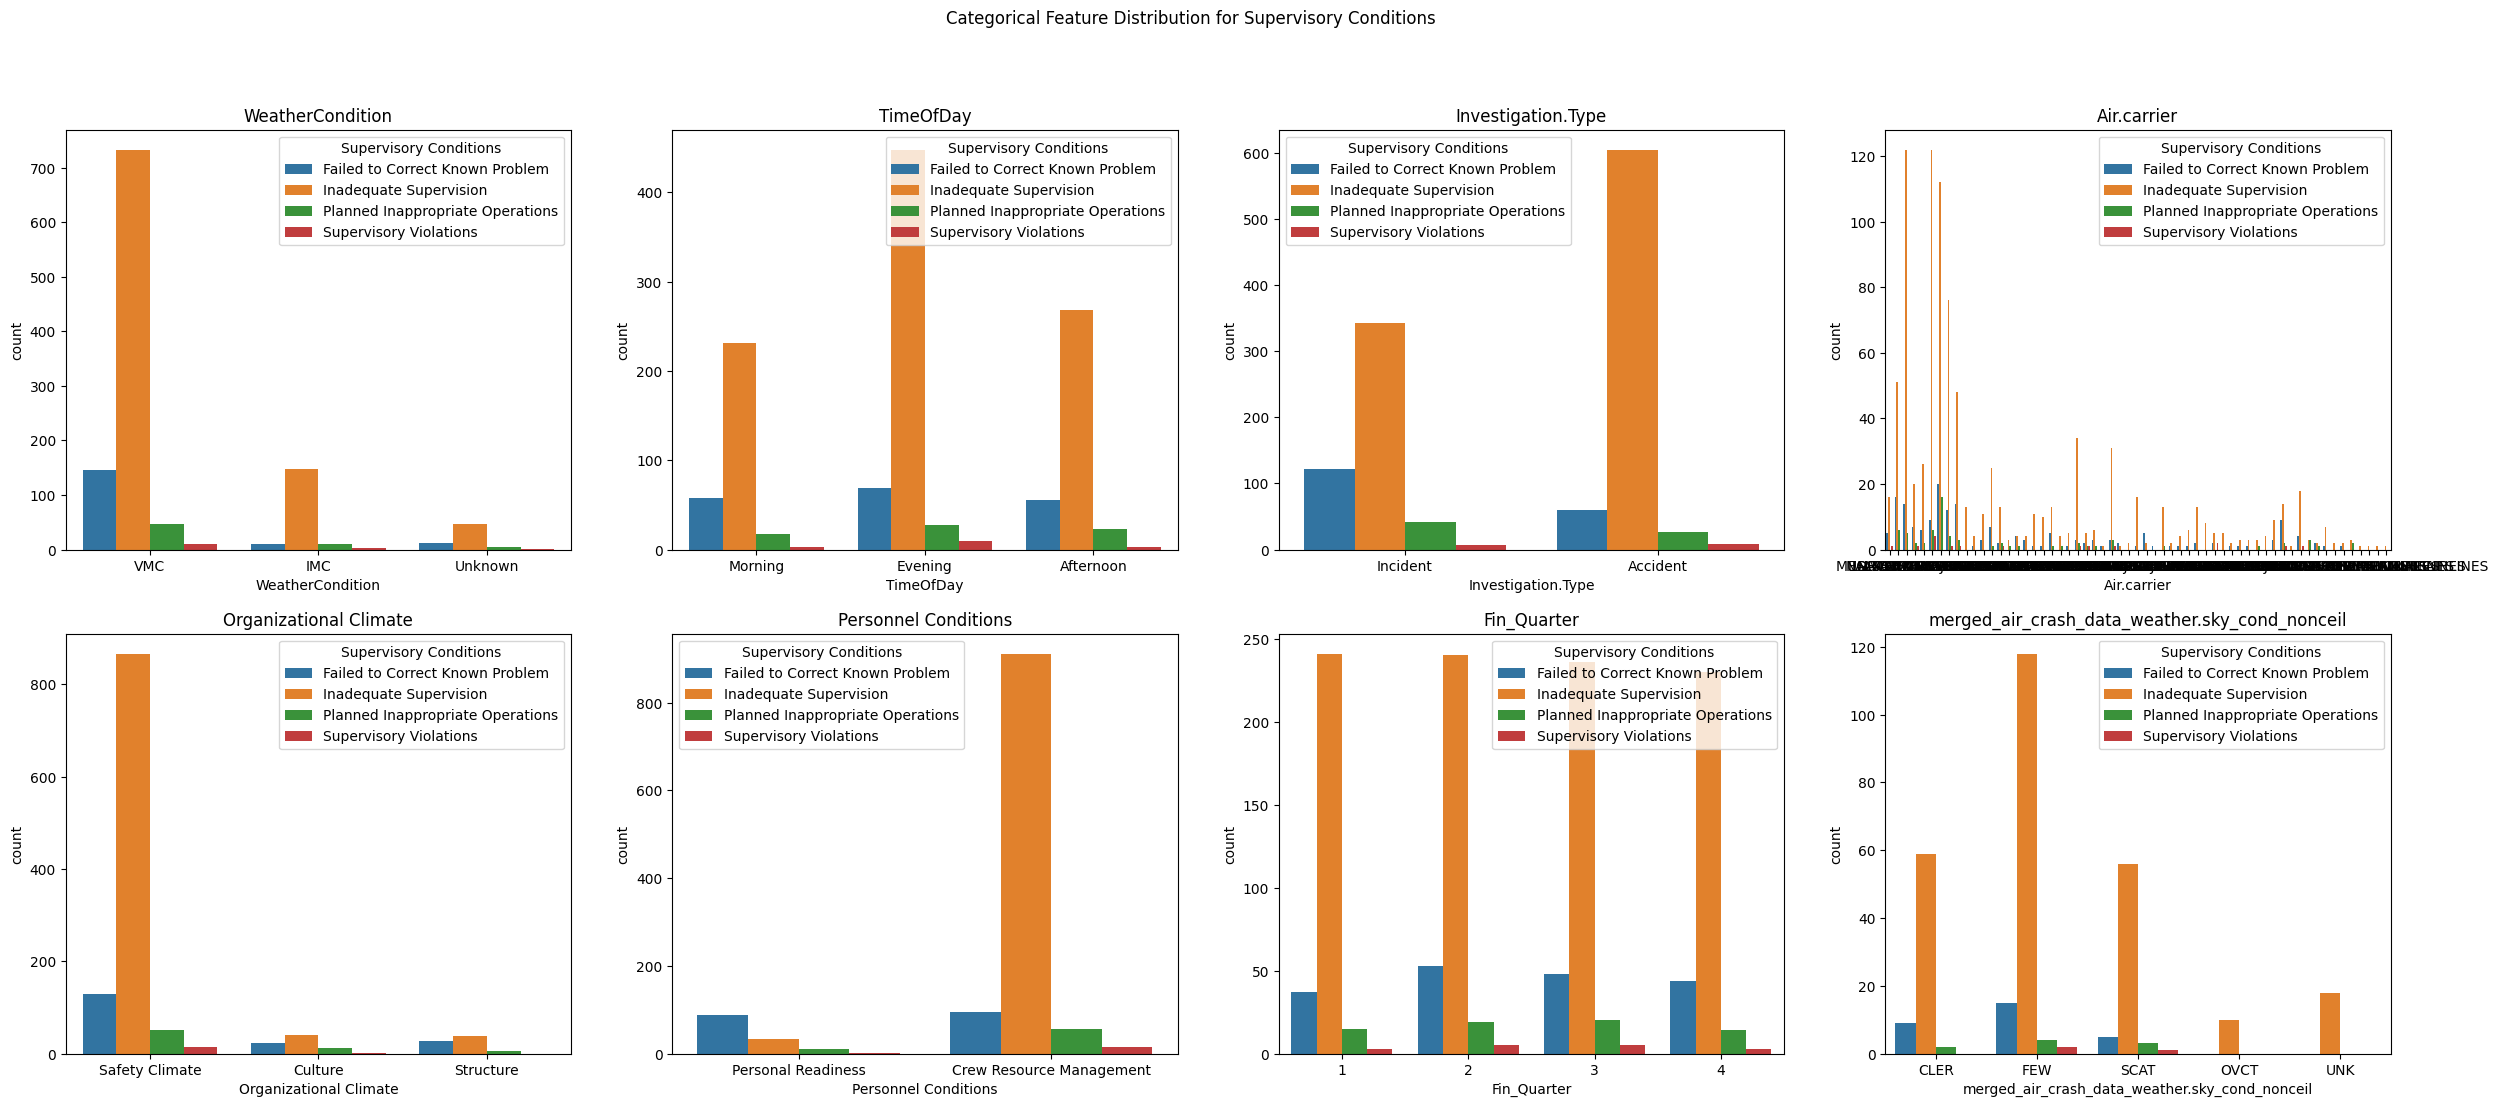

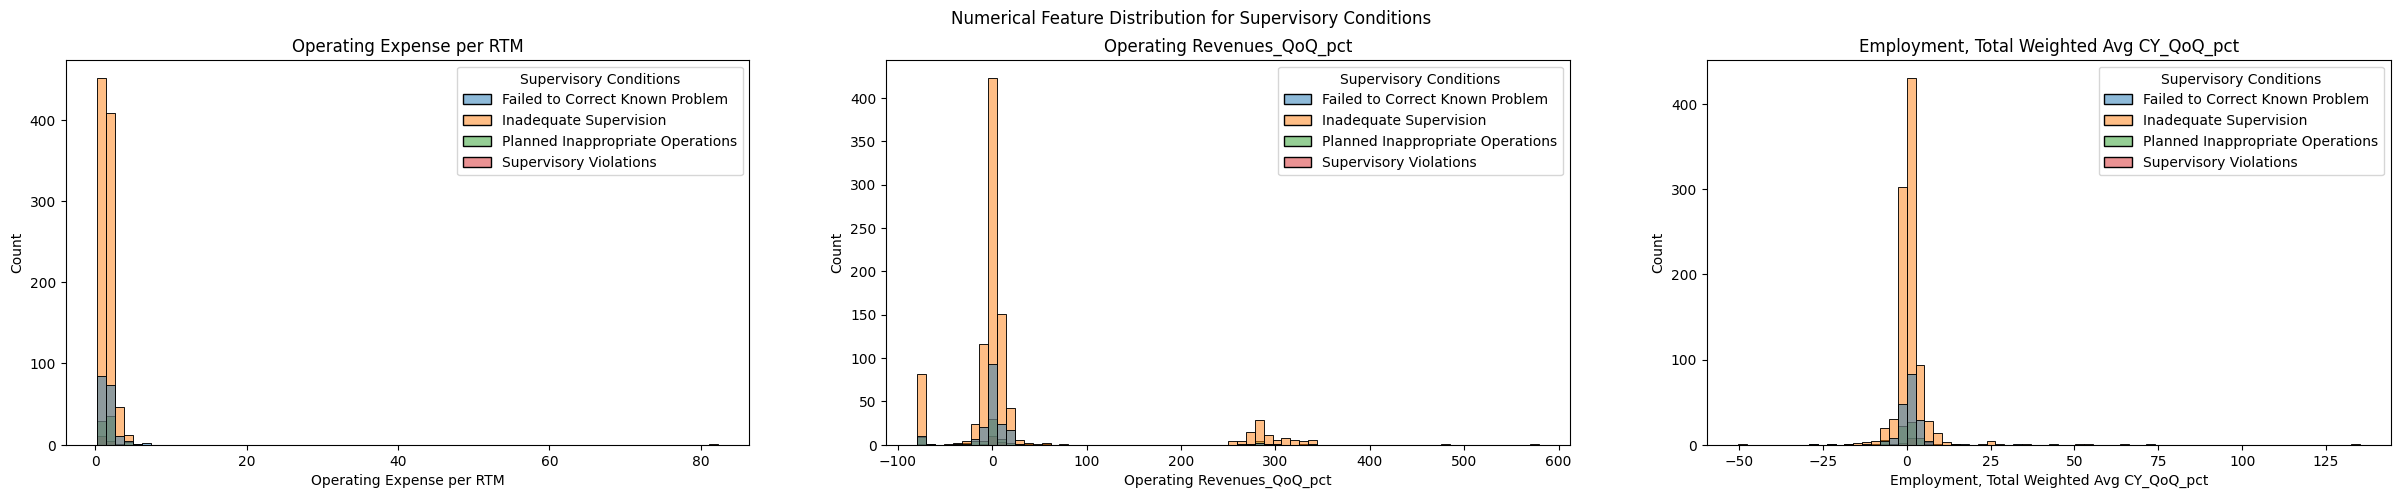

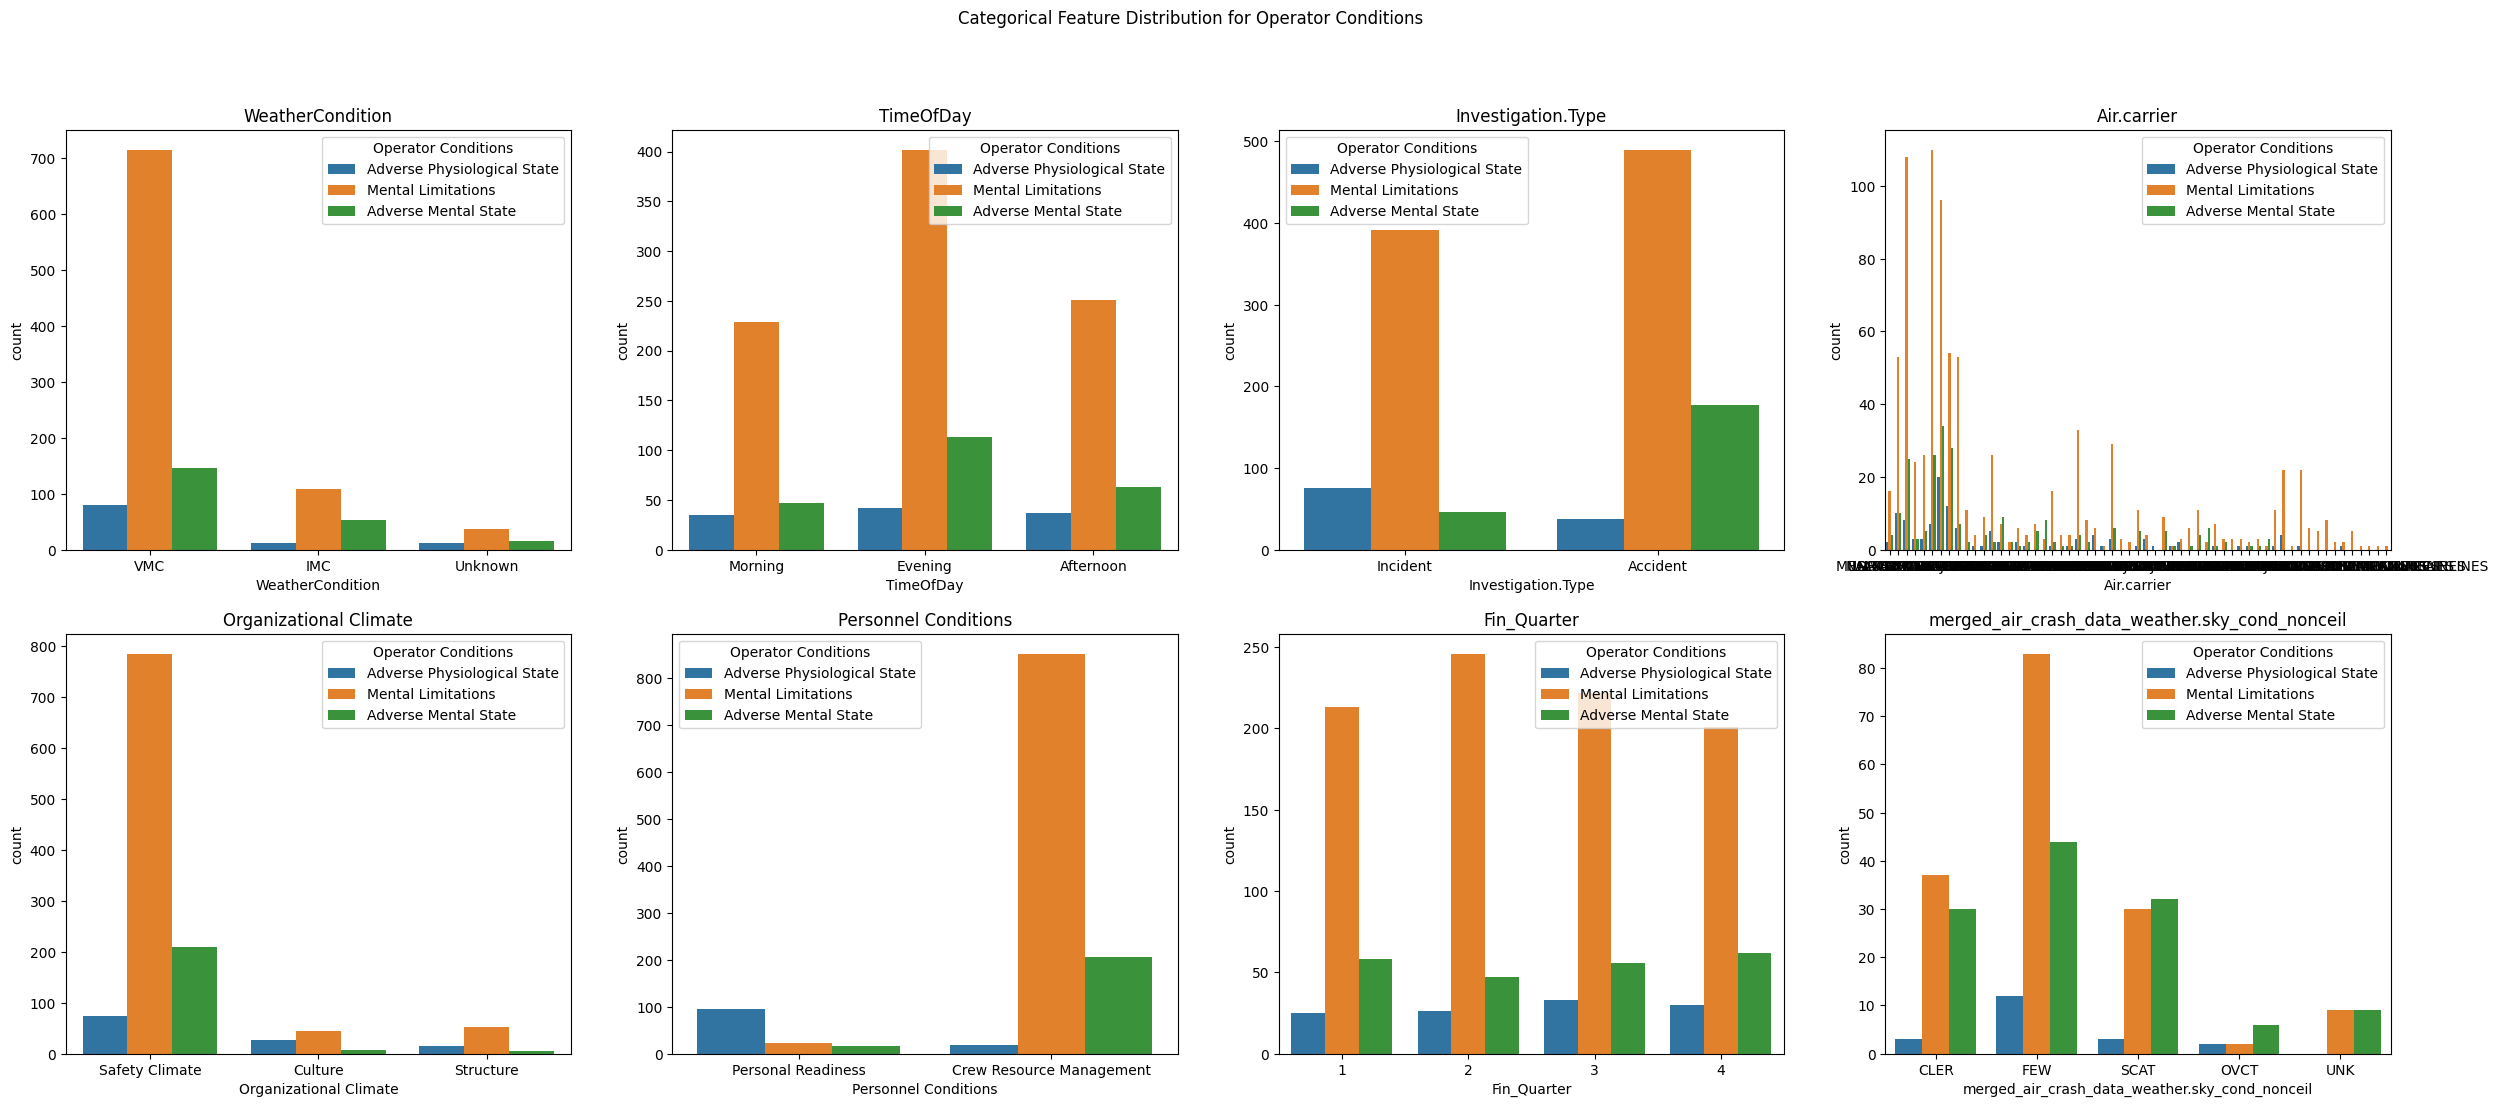

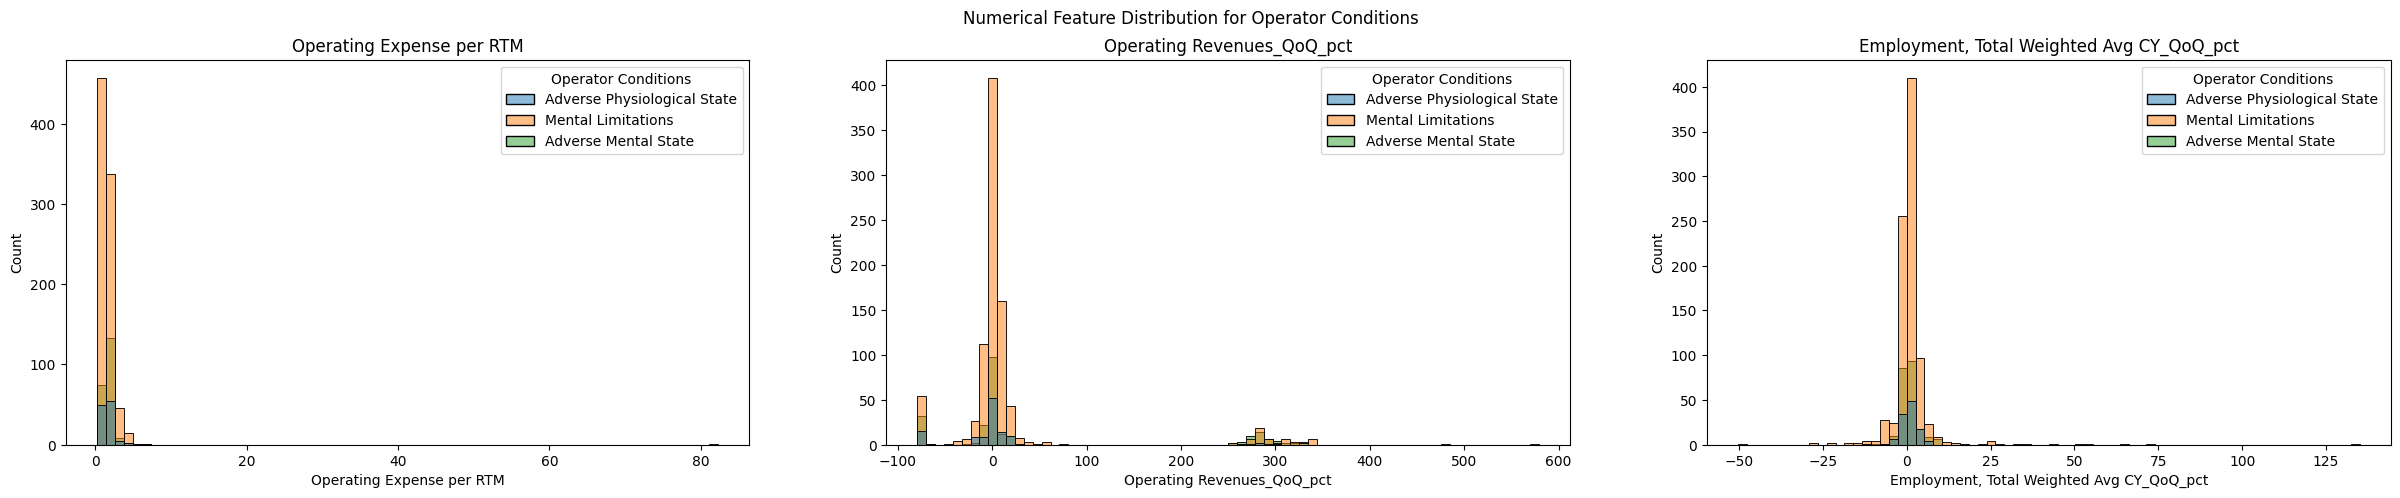

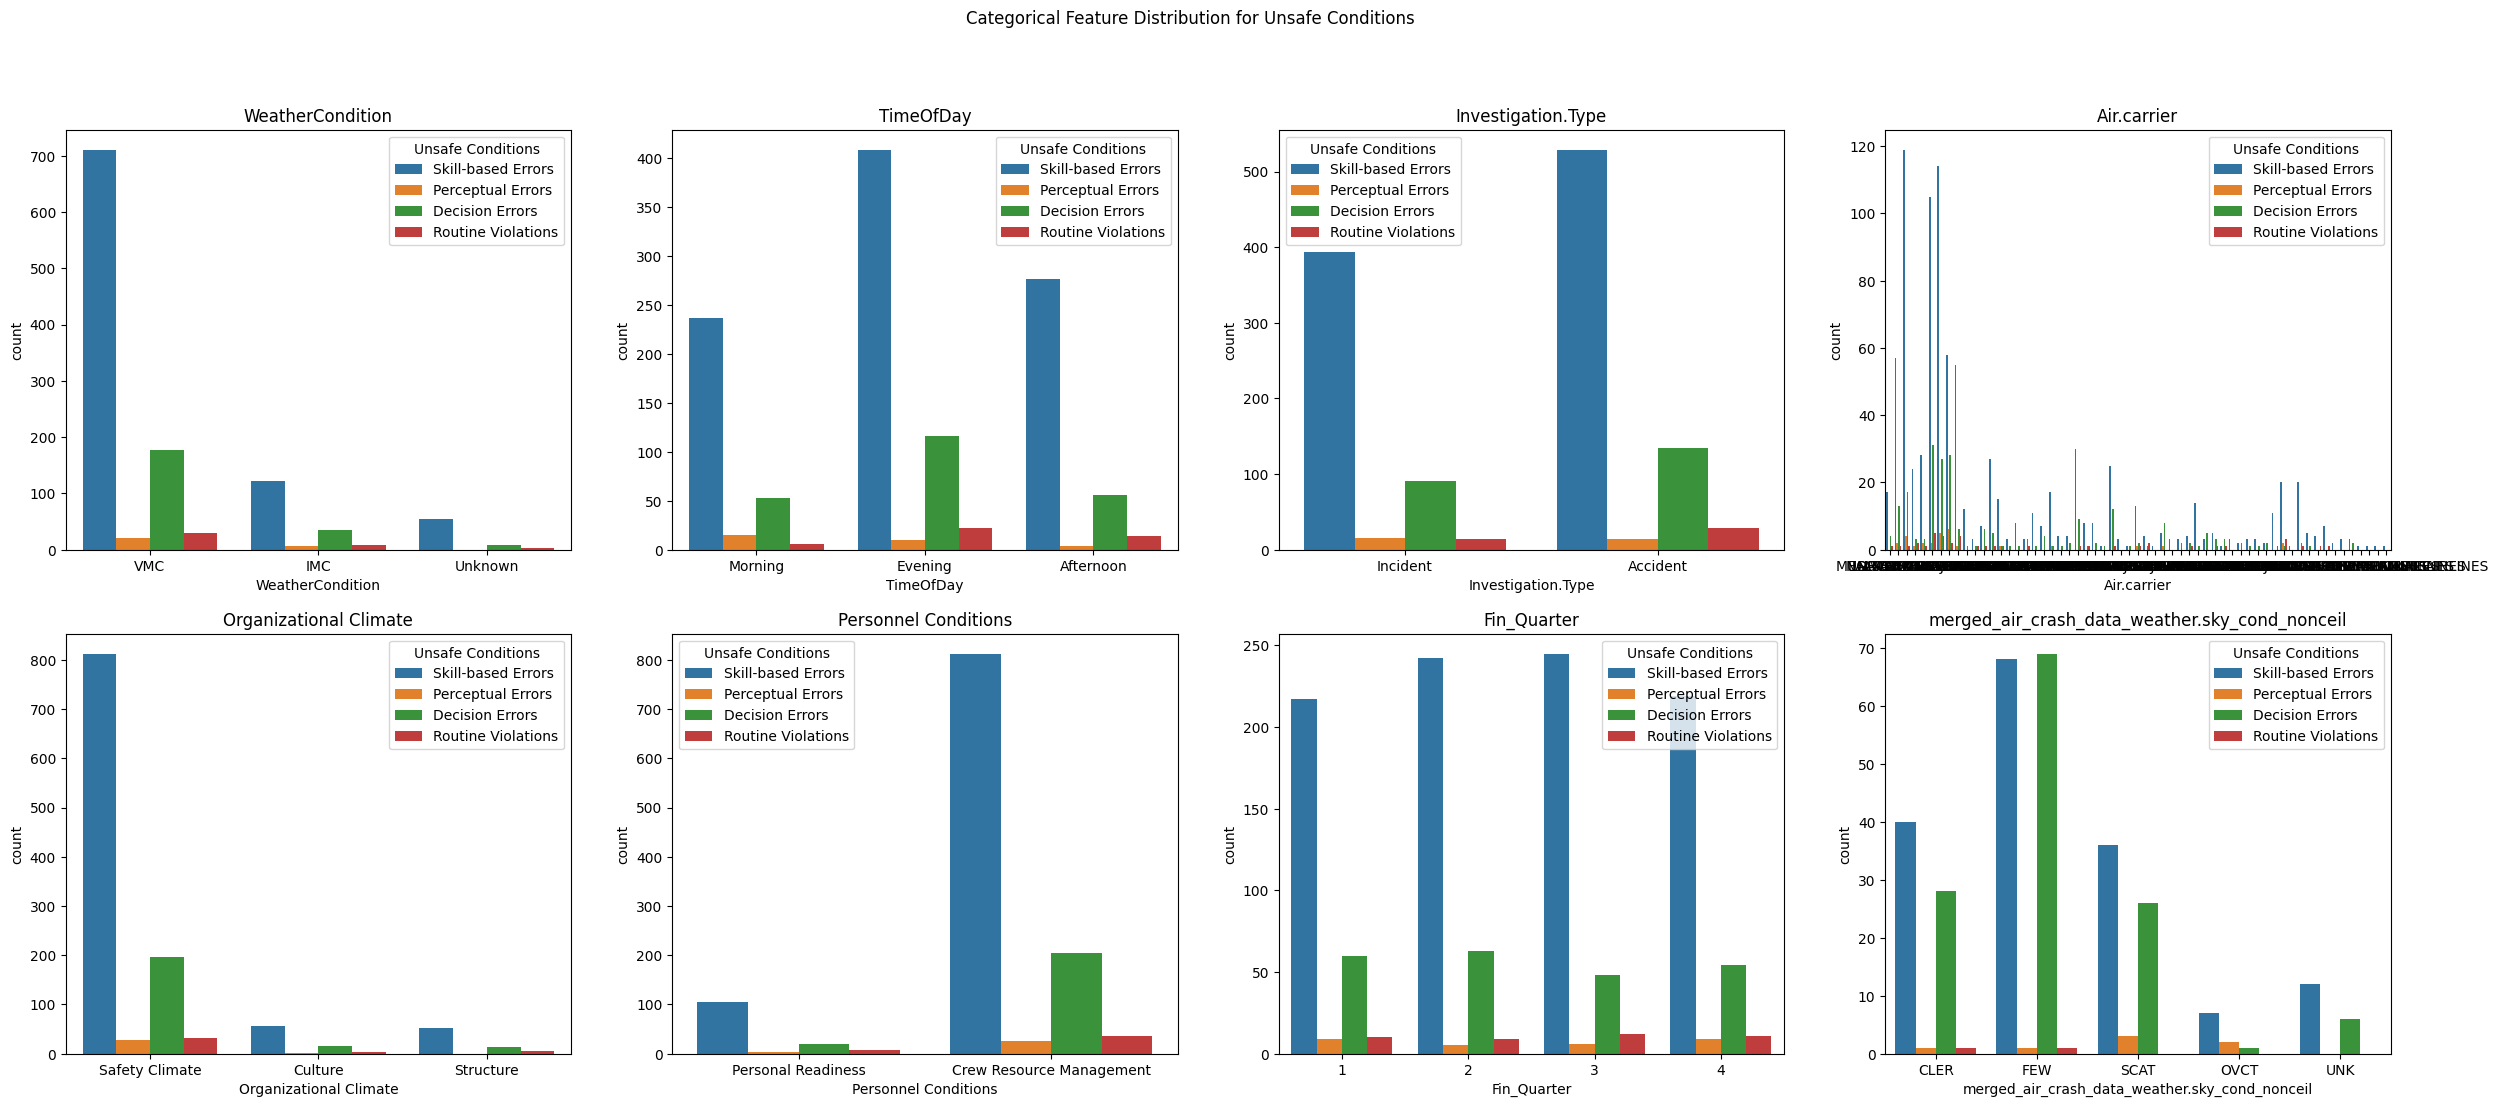

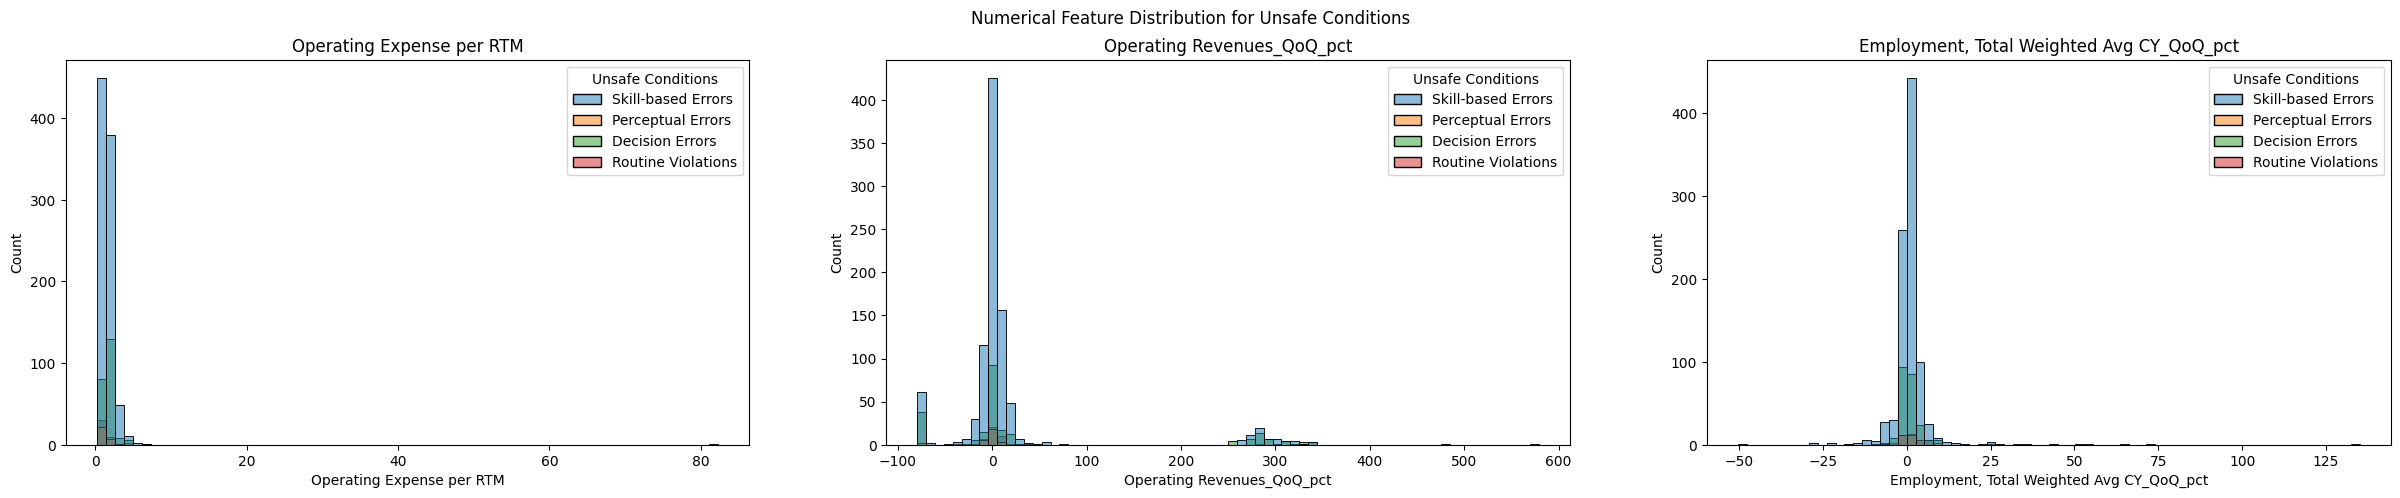

In [6]:
for class_name in target_names:
    rem_names = [name for name in target_names if name != class_name]

    fig, axes = plt.subplots(nrows=2,ncols=4,figsize=(30,12))
    axes = axes.flatten()
    for ax, col in zip(axes, cat_features):
        sns.countplot(data=cat_data.drop(rem_names,axis=1,inplace=False), x=col, hue=class_name, ax=ax)
        ax.set_title(col)
    fig.suptitle("Categorical Feature Distribution for "+class_name)
    plt.savefig('cat_feature_bar_'+class_name+'.png')

    fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(30,5))
    axes = axes.flatten()
    for ax, col in zip(axes, num_features):
        sns.histplot(data=num_data.drop(rem_names,axis=1,inplace=False), x=col, hue=class_name, ax=ax)
        ax.set_title(col)
    fig.suptitle("Numerical Feature Distribution for "+class_name)
    plt.savefig('num_feature_bar_'+class_name+'.png')

# Correlation Heatmap

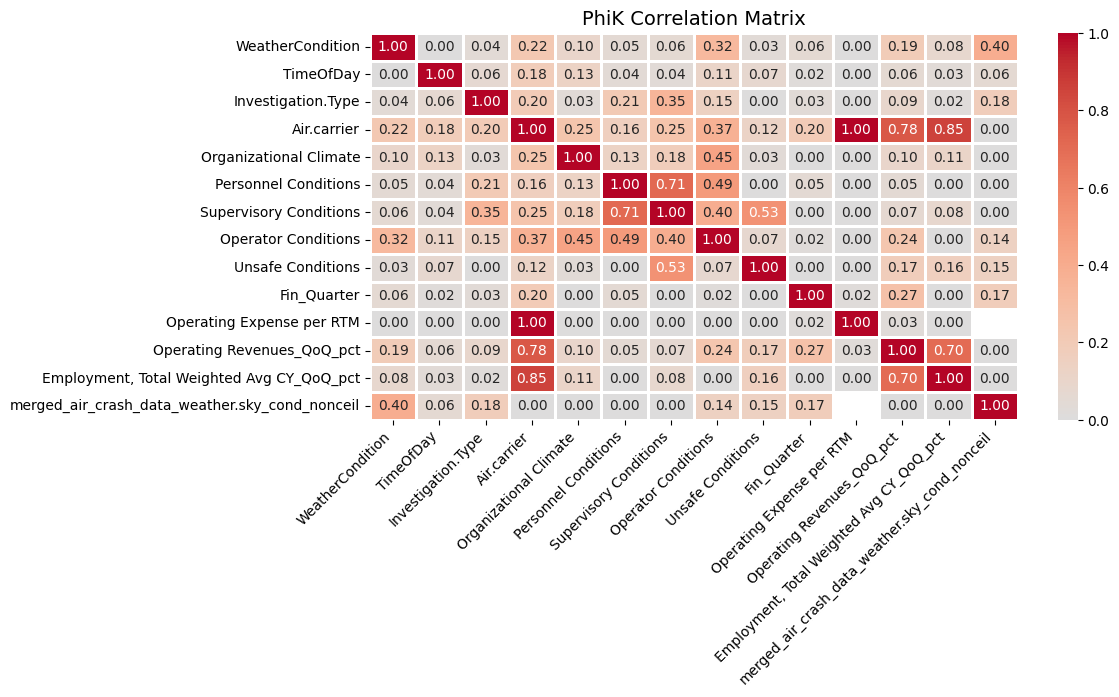

In [10]:

# 2.2 Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = real_data.phik_matrix(interval_cols=['Operating Expense per RTM','Operating Revenues_QoQ_pct','Employment, Total Weighted Avg CY_QoQ_pct',])
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=1)
plt.title('PhiK Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("phi_corr_matrix.png")
plt.show()



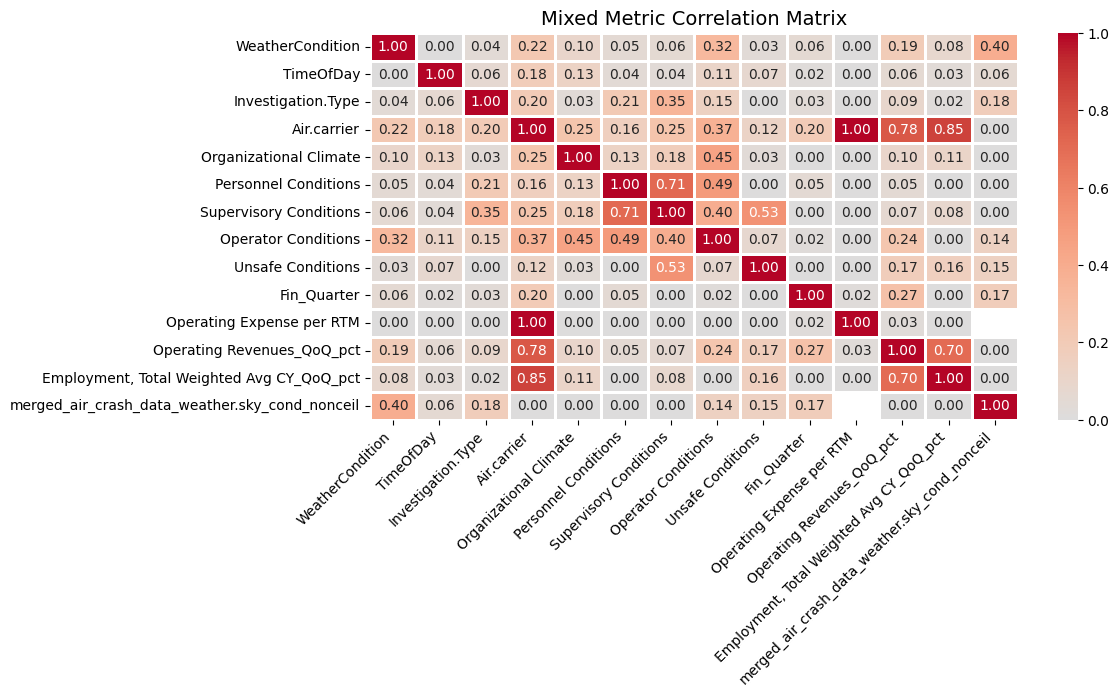

In [11]:
# Mixed Metric (CramerV for cat-cat) heatmap
from dython.nominal import associations
plt.figure(figsize=(12, 8))
real_data[[*cat_features,*target_names]] = real_data[[*cat_features,*target_names]].astype('object')
assoc_matrix = associations(real_data, nominal_columns=real_data.drop(columns=num_features).columns, compute_only=True)['corr']
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=1)
plt.title('Mixed Metric Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("mixed_corr_matrix.png")
plt.show()
